In [194]:
#Load dataset
import pandas as pd
from pathlib import Path
file_name = "/content/drive/MyDrive/AI Programming/Assignment 4/cloudpilot_saas_lead_conversion_business_plan/cloudpilot_saas_lead_conversion_dataset.xlsx"
data_path = Path(file_name)
print("Current dataset path:", data_path)
print("File exists:", data_path.exists())

df = pd.read_excel(data_path)
print("Dataset loaded successfully!")

df.head()

Current dataset path: /content/drive/MyDrive/AI Programming/Assignment 4/cloudpilot_saas_lead_conversion_business_plan/cloudpilot_saas_lead_conversion_dataset.xlsx
File exists: True
Dataset loaded successfully!


,Lead_ID,Lead_Created_Date,Lead_Source,Industry,Region,Company_Size,Contact_Role,Expected_Users,Monthly_Budget_CAD,Preferred_Plan,Email_Engagement_Score,Product_Demo_Attended,Trial_Days_Active,Sales_Calls_Completed,Decision_Maker_Involved,Requested_Discount,Current_Solution,Pain_Point_Fit_Score,Lead_Age_Days,Converted_To_Customer
0,L10001,2026-05-09,Website Form,Professional Services,New York,Small,Finance Manager,50,2353.0,Starter,24.0,No,11,2,No,Yes,NaN,7,6,Yes
1,L10002,2026-02-04,Referral,Education,Ontario,Medium,Marketing Manager,128,7459.0,Enterprise,48.0,Yes,13,4,No,Yes,Other CRM,1,49,Yes
2,L10003,2026-01-31,Website Form,Technology,Quebec,Micro,Owner/Founder,9,691.0,Starter,51.0,No,20,2,No,No,NaN,6,41,Yes
3,L10004,2026-02-19,Website Form,Professional Services,New York,Micro,Sales Manager,12,782.0,Starter,58.0,No,14,2,No,No,Manual Spreadsheet,4,56,Yes
4,L10005,2026-04-16,Webinar,Technology,California,Small,Finance Manager,16,1359.0,Growth,83.0,No,14,3,No,No,NaN,10,55,Yes


In [195]:
#Inspect dataset
df.shape

(380, 20)

In [196]:
df.columns

Index(['Lead_ID', 'Lead_Created_Date', 'Lead_Source', 'Industry', 'Region',
       'Company_Size', 'Contact_Role', 'Expected_Users', 'Monthly_Budget_CAD',
       'Preferred_Plan', 'Email_Engagement_Score', 'Product_Demo_Attended',
       'Trial_Days_Active', 'Sales_Calls_Completed', 'Decision_Maker_Involved',
       'Requested_Discount', 'Current_Solution', 'Pain_Point_Fit_Score',
       'Lead_Age_Days', 'Converted_To_Customer'],
      dtype='object')

In [197]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Lead_ID                  380 non-null    object        
 1   Lead_Created_Date        380 non-null    datetime64[ns]
 2   Lead_Source              380 non-null    object        
 3   Industry                 374 non-null    object        
 4   Region                   380 non-null    object        
 5   Company_Size             380 non-null    object        
 6   Contact_Role             380 non-null    object        
 7   Expected_Users           380 non-null    int64         
 8   Monthly_Budget_CAD       375 non-null    float64       
 9   Preferred_Plan           380 non-null    object        
 10  Email_Engagement_Score   373 non-null    float64       
 11  Product_Demo_Attended    380 non-null    object        
 12  Trial_Days_Active        380 non-nul

In [198]:
df.dtypes

,0
Lead_ID,object
Lead_Created_Date,datetime64[ns]
Lead_Source,object
Industry,object
Region,object
Company_Size,object
Contact_Role,object
Expected_Users,int64
Monthly_Budget_CAD,float64
Preferred_Plan,object


In [199]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Missing values in each column:
Lead_ID                     0
Lead_Created_Date           0
Lead_Source                 0
Industry                    6
Region                      0
Company_Size                0
Contact_Role                0
Expected_Users              0
Monthly_Budget_CAD          5
Preferred_Plan              0
Email_Engagement_Score      7
Product_Demo_Attended       0
Trial_Days_Active           0
Sales_Calls_Completed       0
Decision_Maker_Involved     0
Requested_Discount          0
Current_Solution           84
Pain_Point_Fit_Score        0
Lead_Age_Days               0
Converted_To_Customer       0
dtype: int64

Number of duplicate rows:
0


In [200]:
#Understand the problem
business_problem = "CloudPilot wants to identify which leads are most likely to convert to paying customers"
ml_problem = "This is a classification problem because CloudPilot wants to predict whether a lead is likely to convert."
prediction_goal = "Predict whether a lead is likely to convert: Yes or No."

print("Business Problem:\n", business_problem)
print("\nMachine Learning Problem:\n", ml_problem)
print("\nPrediction Goal:\n", prediction_goal)

Business Problem:
 CloudPilot wants to identify which leads are most likely to convert to paying customers

Machine Learning Problem:
 This is a classification problem because CloudPilot wants to predict whether a lead is likely to convert.

Prediction Goal:
 Predict whether a lead is likely to convert: Yes or No.


In [201]:
#Clean the dataset
df_clean = df.copy()
print("Original dataset shape:")
print(df_clean.shape)

Original dataset shape:
(380, 20)


In [202]:
df_clean = df_clean.drop_duplicates()
print("Dataset shape after removing duplicate rows:")
print(df_clean.shape)
print("\nNumber of duplicate rows after cleaning:")
print(df_clean.duplicated().sum())

Dataset shape after removing duplicate rows:
(380, 20)

Number of duplicate rows after cleaning:
0


In [203]:
numeric_columns = [
    "Expected_Users",
    "Expected_Users",
    "Email_Engagement_Score",
    "Trial_Days_Active",
    "Sales_Calls_Completed",
    "Pain_Point_Fit_Score",
    "Lead_Age_Days"
]
categorical_columns = [
    "Lead_Source",
    "Industry",
    "Region",
    "Company_Size",
    "Contact_Role",
    "Preferred_Plan",
    "Product_Demo_Attended",
    "Decision_Maker_Involved",
    "Requested_Discount",
    "Current_Solution"
]

for column in numeric_columns:
    median_value = df_clean[column].median()
    df_clean[column] = df_clean[column].fillna(median_value)

In [204]:
for column in categorical_columns:
    most_frequent_value = df_clean[column].mode()[0]
    df_clean[column] = df_clean[column].fillna(most_frequent_value)

In [205]:
print("Missing values after cleaning:")
print(df_clean.isnull().sum())

print("\nCleaned dataset preview:")
display(df_clean.head())

Missing values after cleaning:
Lead_ID                    0
Lead_Created_Date          0
Lead_Source                0
Industry                   0
Region                     0
Company_Size               0
Contact_Role               0
Expected_Users             0
Monthly_Budget_CAD         5
Preferred_Plan             0
Email_Engagement_Score     0
Product_Demo_Attended      0
Trial_Days_Active          0
Sales_Calls_Completed      0
Decision_Maker_Involved    0
Requested_Discount         0
Current_Solution           0
Pain_Point_Fit_Score       0
Lead_Age_Days              0
Converted_To_Customer      0
dtype: int64

Cleaned dataset preview:


,Lead_ID,Lead_Created_Date,Lead_Source,Industry,Region,Company_Size,Contact_Role,Expected_Users,Monthly_Budget_CAD,Preferred_Plan,Email_Engagement_Score,Product_Demo_Attended,Trial_Days_Active,Sales_Calls_Completed,Decision_Maker_Involved,Requested_Discount,Current_Solution,Pain_Point_Fit_Score,Lead_Age_Days,Converted_To_Customer
0,L10001,2026-05-09,Website Form,Professional Services,New York,Small,Finance Manager,50,2353.0,Starter,24.0,No,11,2,No,Yes,Manual Spreadsheet,7,6,Yes
1,L10002,2026-02-04,Referral,Education,Ontario,Medium,Marketing Manager,128,7459.0,Enterprise,48.0,Yes,13,4,No,Yes,Other CRM,1,49,Yes
2,L10003,2026-01-31,Website Form,Technology,Quebec,Micro,Owner/Founder,9,691.0,Starter,51.0,No,20,2,No,No,Manual Spreadsheet,6,41,Yes
3,L10004,2026-02-19,Website Form,Professional Services,New York,Micro,Sales Manager,12,782.0,Starter,58.0,No,14,2,No,No,Manual Spreadsheet,4,56,Yes
4,L10005,2026-04-16,Webinar,Technology,California,Small,Finance Manager,16,1359.0,Growth,83.0,No,14,3,No,No,Manual Spreadsheet,10,55,Yes


In [206]:
df = df_clean.copy()

In [207]:
#Define features and taget
target_column = "Converted_To_Customer"
feature_columns = df.drop(columns=[target_column, 'Lead_ID','Lead_Created_Date']).columns.tolist()

X = df[feature_columns]
y = df_clean[target_column]

print("Feature Columns:\n")
display(X.head())
print("Shape of X:", X.shape)


print("\nTarget Column:\n")
display(y.head())
print("Shape of y:", y.shape)
print("\nTarget values:")
print(df[target_column].value_counts())

Feature Columns:



,Lead_Source,Industry,Region,Company_Size,Contact_Role,Expected_Users,Monthly_Budget_CAD,Preferred_Plan,Email_Engagement_Score,Product_Demo_Attended,Trial_Days_Active,Sales_Calls_Completed,Decision_Maker_Involved,Requested_Discount,Current_Solution,Pain_Point_Fit_Score,Lead_Age_Days
0,Website Form,Professional Services,New York,Small,Finance Manager,50,2353.0,Starter,24.0,No,11,2,No,Yes,Manual Spreadsheet,7,6
1,Referral,Education,Ontario,Medium,Marketing Manager,128,7459.0,Enterprise,48.0,Yes,13,4,No,Yes,Other CRM,1,49
2,Website Form,Technology,Quebec,Micro,Owner/Founder,9,691.0,Starter,51.0,No,20,2,No,No,Manual Spreadsheet,6,41
3,Website Form,Professional Services,New York,Micro,Sales Manager,12,782.0,Starter,58.0,No,14,2,No,No,Manual Spreadsheet,4,56
4,Webinar,Technology,California,Small,Finance Manager,16,1359.0,Growth,83.0,No,14,3,No,No,Manual Spreadsheet,10,55


Shape of X: (380, 17)

Target Column:



,Converted_To_Customer
0,Yes
1,Yes
2,Yes
3,Yes
4,Yes


Shape of y: (380,)

Target values:
Converted_To_Customer
Yes    355
No      25
Name: count, dtype: int64


In [208]:
#Spit train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:")
print(X_train.shape)

print("X_test shape:")
print(X_test.shape)

print("y_train shape:")
print(y_train.shape)

print("y_test shape:")
print(y_test.shape)

X_train shape:
(304, 17)
X_test shape:
(76, 17)
y_train shape:
(304,)
y_test shape:
(76,)


In [209]:
print("Target distribution in training set:")
print("-" * 50)

train_distribution = y_train.value_counts()

display(train_distribution)

print("Target distribution in testing set:")
print("-" * 50)

test_distribution = y_test.value_counts()

display(test_distribution)

Target distribution in training set:
--------------------------------------------------


,count
Converted_To_Customer,
Yes,284
No,20


Target distribution in testing set:
--------------------------------------------------


,count
Converted_To_Customer,
Yes,71
No,5


In [210]:
#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
numeric_columns = [
    "Expected_Users",
    "Expected_Users",
    "Email_Engagement_Score",
    "Trial_Days_Active",
    "Sales_Calls_Completed",
    "Pain_Point_Fit_Score",
    "Lead_Age_Days"
]
categorical_columns = [
    "Lead_Source",
    "Industry",
    "Region",
    "Company_Size",
    "Contact_Role",
    "Preferred_Plan",
    "Product_Demo_Attended",
    "Decision_Maker_Involved",
    "Requested_Discount",
    "Current_Solution"
]

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", encoder, categorical_columns),
        ("numerical", "passthrough", numeric_columns)
    ]
)

print("Preprocessor has been created successfully.")

Preprocessor has been created successfully.


In [211]:
X_train_processed = preprocessor.fit_transform(X_train)
print("X_train preprocessing completed!")

X_test_processed = preprocessor.transform(X_test)
print("X_test preprocessing completed!")

print("Summary of preprocessing shapes:")
print("X_train before preprocessing:", X_train.shape)
print("X_train after preprocessing:", X_train_processed.shape)
print("X_test before preprocessing:", X_test.shape)
print("X_test after preprocessing:", X_test_processed.shape)

X_train preprocessing completed!
X_test preprocessing completed!
Summary of preprocessing shapes:
X_train before preprocessing: (304, 17)
X_train after preprocessing: (304, 53)
X_test before preprocessing: (76, 17)
X_test after preprocessing: (76, 53)


In [212]:
# Get the new feature names created from categorical variables
encoded_categorical_columns = preprocessor.named_transformers_["categorical"].get_feature_names_out(categorical_columns)

# Combine encoded categorical feature names with numerical feature names
processed_feature_names = list(encoded_categorical_columns) + numeric_columns

print("Number of processed features:", len(processed_feature_names))

print(processed_feature_names)

Number of processed features: 53
['Lead_Source_Email Campaign', 'Lead_Source_LinkedIn Ad', 'Lead_Source_Organic Search', 'Lead_Source_Referral', 'Lead_Source_Trade Show', 'Lead_Source_Webinar', 'Lead_Source_Website Form', 'Industry_Education', 'Industry_Finance', 'Industry_Healthcare', 'Industry_Manufacturing', 'Industry_Professional Services', 'Industry_Retail', 'Industry_Technology', 'Region_Alberta', 'Region_British Columbia', 'Region_California', 'Region_New York', 'Region_Ontario', 'Region_Quebec', 'Region_Texas', 'Company_Size_Large', 'Company_Size_Medium', 'Company_Size_Micro', 'Company_Size_Small', 'Contact_Role_Finance Manager', 'Contact_Role_IT Manager', 'Contact_Role_Marketing Manager', 'Contact_Role_Operations Manager', 'Contact_Role_Owner/Founder', 'Contact_Role_Sales Manager', 'Preferred_Plan_Enterprise', 'Preferred_Plan_Growth', 'Preferred_Plan_Professional', 'Preferred_Plan_Starter', 'Product_Demo_Attended_No', 'Product_Demo_Attended_Yes', 'Decision_Maker_Involved_No', 

In [213]:
# Convert processed training data into a DataFrame
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns = processed_feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=processed_feature_names,
    index=X_test.index
)

display(X_train_processed_df.head())

,Lead_Source_Email Campaign,Lead_Source_LinkedIn Ad,Lead_Source_Organic Search,Lead_Source_Referral,Lead_Source_Trade Show,Lead_Source_Webinar,Lead_Source_Website Form,Industry_Education,Industry_Finance,Industry_Healthcare,...,Current_Solution_Other CRM,Current_Solution_Salesforce,Current_Solution_Zoho,Expected_Users,Expected_Users,Email_Engagement_Score,Trial_Days_Active,Sales_Calls_Completed,Pain_Point_Fit_Score,Lead_Age_Days
224,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,15.0,15.0,72.0,18.0,3.0,7.0,4.0
101,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,48.0,48.0,76.0,17.0,3.0,5.0,39.0
216,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,180.0,180.0,56.0,18.0,2.0,5.0,47.0
30,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,10.0,10.0,48.0,16.0,4.0,4.0,35.0
262,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,31.0,31.0,53.0,3.0,3.0,7.0,70.0


In [214]:
#Training a Decision Tree Model
from sklearn.tree import DecisionTreeClassifier
decision_tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

print("Decision Tree model has been created.")

Decision Tree model has been created.


In [215]:
decision_tree_model.fit(X_train_processed_df, y_train)
print("Decision Tree model has been trained successfully.")

Decision Tree model has been trained successfully.


In [216]:
print("Decision Tree Model Information")

print("-" * 50)

print(decision_tree_model)

Decision Tree Model Information
--------------------------------------------------
DecisionTreeClassifier(max_depth=4, random_state=42)


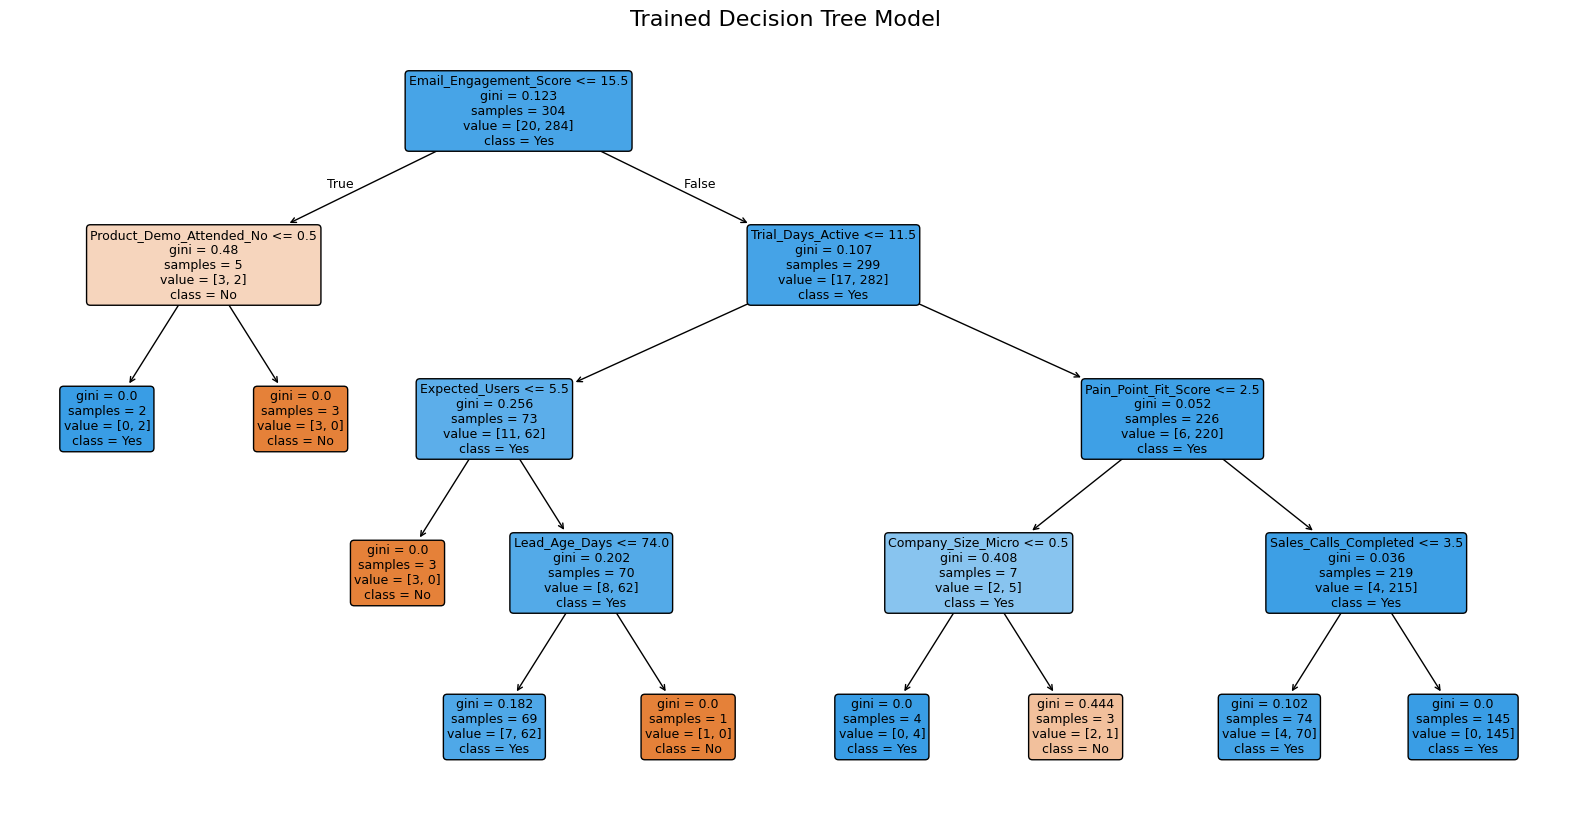

In [217]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree_model,
    feature_names=X_train_processed_df.columns,
    class_names=decision_tree_model.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Trained Decision Tree Model", fontsize=16)

plt.show()

In [218]:
tree_depth = decision_tree_model.get_depth()
tree_leaves = decision_tree_model.get_n_leaves()

print("Decision Tree depth:", tree_depth)
print("Number of leaf nodes:", tree_leaves)

Decision Tree depth: 4
Number of leaf nodes: 9


In [219]:
#Evaluating the Decision Tree Model
y_pred_dt = decision_tree_model.predict(X_test_processed_df)
print("Decision Tree predictions have been created successfully.")

Decision Tree predictions have been created successfully.


In [220]:
dt_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_dt
})

print("Actual vs Predicted Values")

print("-" * 50)

display(dt_results.head(10))

Actual vs Predicted Values
--------------------------------------------------


,Actual,Predicted
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [221]:
from sklearn.metrics import accuracy_score

dt_test_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Test Accuracy:")
print(dt_test_accuracy)

Decision Tree Test Accuracy:
0.9078947368421053


In [222]:
y_train_pred_dt = decision_tree_model.predict(X_train_processed_df)

dt_train_accuracy = accuracy_score(y_train, y_train_pred_dt)

dt_test_accuracy = accuracy_score(y_test, y_pred_dt)

dt_accuracy_table = pd.DataFrame({
    "Evaluation Set": ["Training Set", "Testing Set"],
    "Accuracy": [dt_train_accuracy, dt_test_accuracy]
})

display(dt_accuracy_table)

,Evaluation Set,Accuracy
0,Training Set,0.960526
1,Testing Set,0.907895


In [223]:
#Confusion Matrix for Decision Tree
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [224]:
class_labels = ["No", "Yes"]

cm_dt = confusion_matrix(y_test, y_pred_dt, labels=class_labels)

cm_dt_table = pd.DataFrame(
    cm_dt,
    index=["Actual No", "Actual Yes"],
    columns=["Predicted No", "Predicted Yes"]
)

print("Decision Tree Confusion Matrix")
print("-" * 50)
display(cm_dt_table)

Decision Tree Confusion Matrix
--------------------------------------------------


,Predicted No,Predicted Yes
Actual No,0,5
Actual Yes,2,69


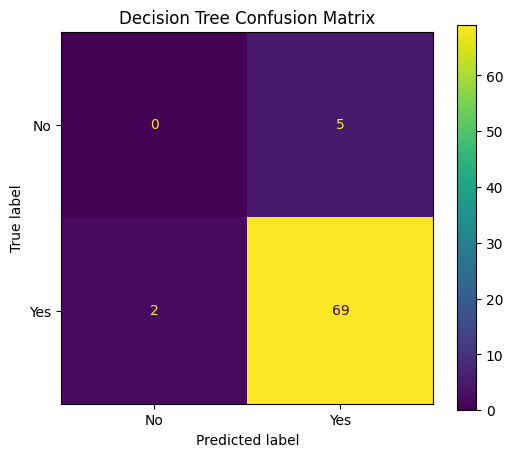

In [225]:
fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=class_labels
)

disp.plot(ax=ax, values_format="d")

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [226]:
#Accuracy, Precision, Recall, and F1-Score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

In [227]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, pos_label="Yes", zero_division=0)
dt_recall = recall_score(y_test, y_pred_dt, pos_label="Yes", zero_division=0)
dt_f1 = f1_score(y_test, y_pred_dt, pos_label="Yes", zero_division=0)

print("Decision Tree Classification Report")
print("-" * 50)
print(classification_report(y_test, y_pred_dt, zero_division=0))

Decision Tree Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

          No       0.00      0.00      0.00         5
         Yes       0.93      0.97      0.95        71

    accuracy                           0.91        76
   macro avg       0.47      0.49      0.48        76
weighted avg       0.87      0.91      0.89        76



In [228]:
#Understanding Overfitting in Decision Trees
from sklearn.tree import DecisionTreeClassifier
overfit_tree_model = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

overfit_tree_model.fit(X_train_processed_df, y_train)

print("Overfitted Decision Tree model has been trained.")

Overfitted Decision Tree model has been trained.


In [229]:
y_train_pred_overfit = overfit_tree_model.predict(X_train_processed_df)

y_test_pred_overfit = overfit_tree_model.predict(X_test_processed_df)

overfit_train_accuracy = accuracy_score(y_train, y_train_pred_overfit)

overfit_test_accuracy = accuracy_score(y_test, y_test_pred_overfit)

print("Overfitted Tree Training Accuracy:", overfit_train_accuracy)
print("Overfitted Tree Testing Accuracy:", overfit_test_accuracy)

Overfitted Tree Training Accuracy: 1.0
Overfitted Tree Testing Accuracy: 0.8552631578947368


In [230]:
print('''
Overfitting Assessment

A Decision Tree with no maximum depth (default) grows until every leaf is pure — it memorises the training data perfectly, resulting in 100% training accuracy.
When the model is then evaluated on the unseen test set, the accuracy typically drops significantly.

- If training accuracy ≈ 100% and testing accuracy is noticeably lower, this is a classic sign of overfitting.
- The model has memorised the training examples instead of learning generalisable patterns.
- To reduce overfitting, we can limit tree depth (max_depth), require a minimum number of samples per leaf (min_samples_leaf), or use a pruned/regularised tree.
''')


Overfitting Assessment

A Decision Tree with no maximum depth (default) grows until every leaf is pure — it memorises the training data perfectly, resulting in 100% training accuracy.
When the model is then evaluated on the unseen test set, the accuracy typically drops significantly.

- If training accuracy ≈ 100% and testing accuracy is noticeably lower, this is a classic sign of overfitting.
- The model has memorised the training examples instead of learning generalisable patterns.
- To reduce overfitting, we can limit tree depth (max_depth), require a minimum number of samples per leaf (min_samples_leaf), or use a pruned/regularised tree.

